In [5]:
# from pathlib import Path

# from matplotlib import colors
# matplotlib.use('Agg')
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# from datetime import datetime
# from datetime import timedelta

data_dir = Path("/Users/dal674840/Downloads/20240629_parquet")


files = sorted(data_dir.glob("*19.2235E_34.4244S*_lvl0.pq"))

dfs = []

for f in files:
    print(f.name)

    d = pd.read_parquet(f)

    d["datetime"] = pd.to_datetime(d["datetime"])

    dfs.append(d)

df = pd.concat(dfs, ignore_index=True)
print(df.columns)


# ==========================================================
# Keep only elevation >20°
# ==========================================================

"""dfm = df[(df["elev"] > 30)&(df['sigma_phi_quality_flag_1']==0)&(~df['prn'].str.contains('R'))].copy()

d
print(df.columns)


plt.scatter(dfm["minbin"], dfm['s4_1'])
#plt.xlim(pd.Timestamp('2024-06-29'),pd.Timestamp('2024-06-30'))
plt.ylim(0,1)
plt.show()"""

scintpi3_20240629_0000_19.2235E_34.4244S_v326f_lvl0.pq
scintpi3_20240629_0003_19.2235E_34.4244S_v326f_lvl0.pq
scintpi3_20240629_0400_19.2235E_34.4244S_v326f_lvl0.pq
scintpi3_20240629_0800_19.2235E_34.4244S_v326f_lvl0.pq
scintpi3_20240629_1200_19.2235E_34.4244S_v326f_lvl0.pq
scintpi3_20240629_1600_19.2235E_34.4244S_v326f_lvl0.pq
scintpi3_20240629_2000_19.2235E_34.4244S_v326f_lvl0.pq
Index(['cons', 'svid', 'elev', 'azim', 'snr1', 'snr2', 'cph1', 'cph2', 'rng1',
       'rng2', 'datetime'],
      dtype='object')


'dfm = df[(df["elev"] > 30)&(df[\'sigma_phi_quality_flag_1\']==0)&(~df[\'prn\'].str.contains(\'R\'))].copy()\n\nd\nprint(df.columns)\n\n\nplt.scatter(dfm["minbin"], dfm[\'s4_1\'])\n#plt.xlim(pd.Timestamp(\'2024-06-29\'),pd.Timestamp(\'2024-06-30\'))\nplt.ylim(0,1)\nplt.show()'

In [9]:
from pathlib import Path

import pandas as pd

# Folder containing parquet files
data_dir = Path("/Users/dal674840/Downloads/20241010_parquet")

# Read all files for the station
files = sorted(data_dir.glob("*19.2235E_34.4244S*_lvl0.pq"))

print(f"Found {len(files)} files")

dfs = []

for f in files:
    print(f"Reading {f.name}")

    df = pd.read_parquet(f)

    # Convert to datetime if needed
    df["datetime"] = pd.to_datetime(df["datetime"])

    dfs.append(df)

# Concatenate all files
day_df = pd.concat(dfs, ignore_index=True)

# Sort chronologically
day_df = day_df.sort_values("datetime").reset_index(drop=True)

# Optional: remove duplicate rows
day_df = day_df.drop_duplicates()

print(day_df.shape)
print(day_df.head())

Found 7 files
Reading scintpi3_20241010_0000_19.2235E_34.4244S_v326f_lvl0.pq
Reading scintpi3_20241010_0003_19.2235E_34.4244S_v326f_lvl0.pq
Reading scintpi3_20241010_0400_19.2235E_34.4244S_v326f_lvl0.pq
Reading scintpi3_20241010_0800_19.2235E_34.4244S_v326f_lvl0.pq
Reading scintpi3_20241010_1200_19.2235E_34.4244S_v326f_lvl0.pq
Reading scintpi3_20241010_1600_19.2235E_34.4244S_v326f_lvl0.pq
Reading scintpi3_20241010_2000_19.2235E_34.4244S_v326f_lvl0.pq
(62250566, 11)
   cons  svid  elev  azim  snr1  snr2          cph1          cph2  \
0     0    23    32    28    43    43  1.123023e+08  8.750842e+07   
1     0    21    14   246    40     0  1.171107e+08  0.000000e+00   
2     2    21    46    48    45    49  1.238709e+08  9.491413e+07   
3     3     7    11   102    37    42  2.039133e+08  1.576786e+08   
4     3    10    13    89    38    43  2.010430e+08  1.554592e+08   

           rng1          rng2                   datetime  
0  2.137038e+07  2.137037e+07 2024-10-10 00:00:18.187500

In [10]:
output_file = data_dir / "20241010_lvl0_day.parquet"

day_df.to_parquet(
    output_file,
    index=False,
    compression="brotli",
    compression_level=6,
)

print(f"Saved: {output_file}")

Saved: /Users/dal674840/Downloads/20241010_parquet/20241010_lvl0_day.parquet


scintpi3_20240629_0003_19.2235E_34.4244S_v326f_lvl3.pq


scintpi3_20240629_0400_19.2235E_34.4244S_v326f_lvl3.pq
scintpi3_20240629_0800_19.2235E_34.4244S_v326f_lvl3.pq
scintpi3_20240629_1200_19.2235E_34.4244S_v326f_lvl3.pq
scintpi3_20240629_1600_19.2235E_34.4244S_v326f_lvl3.pq
scintpi3_20240629_2000_19.2235E_34.4244S_v326f_lvl3.pq
Index(['minbin', 'prn', 'index', 'cons', 'svid', 'elev', 'azim', 'snr1',
       'snr2', 'cph1', 'cph2', 'rng1', 'rng2', 'datetime', 'sig_1', 'sig_2',
       'sig_3', 'freq_1', 'freq_2', 'freq_3', 'detrended_cph1',
       'cycleslips_cph1', 'edgegap_mask_cph1', 'detrended_cph2',
       'cycleslips_cph2', 'edgegap_mask_cph2', 'v1', 'v2', 'clock_term',
       'detrended_noclk_cph1', 'detrended_noclk_cph2', 'tec_cph12',
       'tec_rng12', 'sigma_phi_1', 'n_sigphi_1', 'n_cycleslip_1', 's4_1',
       's4_corrected_1', 'sigma_phi_2', 'n_sigphi_2', 'n_cycleslip_2', 's4_2',
       's4_corrected_2', 'sigma_phi_quality_flag_1', 's4_quality_flag_1',
       'sigma_phi_quality_flag_2', 's4_quality_flag_2'],
      dtype='object')

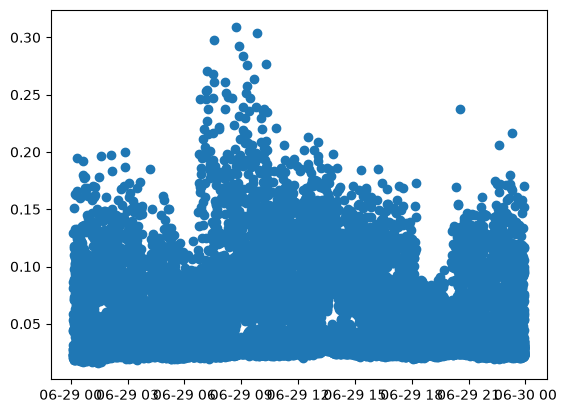

In [ ]:
from pathlib import Path

# from datetime import datetime
# from datetime import timedelta
# from matplotlib import colors
# matplotlib.use('Agg')
import pandas as pd

# from pathlib import Path


data_dir = Path("/Users/dal674840/Downloads/20240629")


files = sorted(data_dir.glob("*19.2235E_34.4244S*_lvl3.pq"))

dfs = []

for f in files:
    print(f.name)

    d = pd.read_parquet(f)

    d["minbin"] = pd.to_datetime(d["minbin"])

    dfs.append(d)

df = pd.concat(dfs, ignore_index=True)
print(df.keys())

# ==========================================================
# Keep only elevation >20°
# ==========================================================
# %%
df_m = df[(df["elev"] > 30) & (df["sigma_phi_quality_flag_1"] == 0)].copy()

# plt.scatter(df["minbin"], df["s4_1"])
plt.scatter(df_m["minbin"], df_m[""])
plt.show()

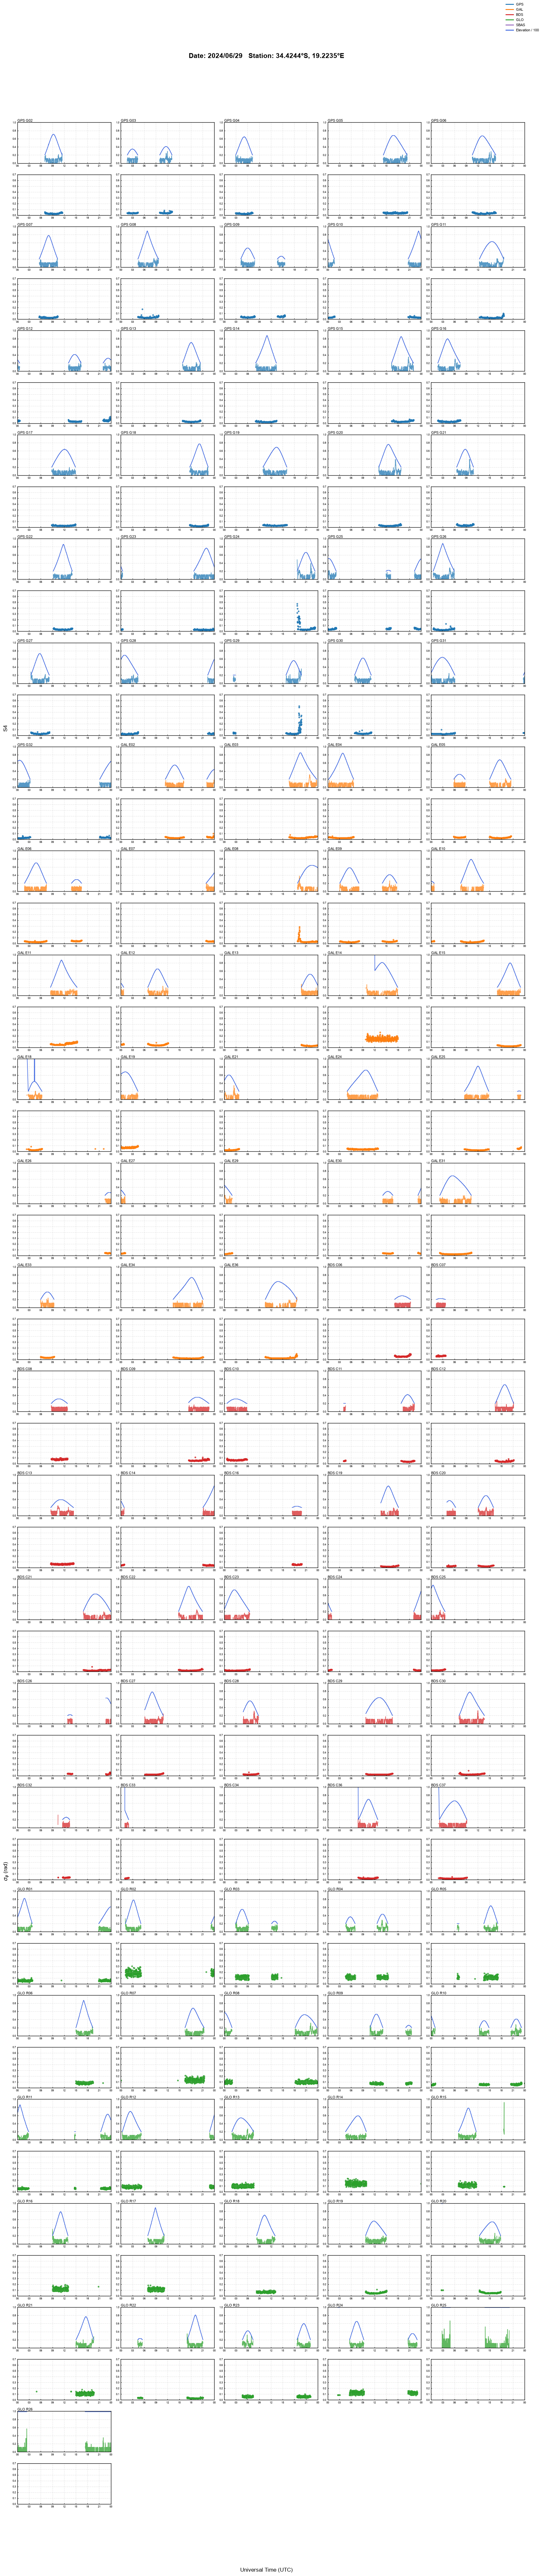

In [4]:
from math import ceil

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd

N_COLS = 5

CONST_ORDER = ["GPS", "GAL", "BDS", "GLO", "SBAS"]
CONST_COLORS = {
    "GPS": "tab:blue",
    "GAL": "tab:orange",
    "BDS": "tab:red",
    "GLO": "tab:green",
    "SBAS": "tab:purple",
}
df = pd.read_parquet(
    "/Users/dal674840/scintkit/src/scintkit/sc4_reading/lvl3_19.2235E_34.4244S_20241010_.pq"
)
df = df[df["elev"] >= 20]
df["minbin"] = pd.to_datetime(df["minbin"])
df = df.sort_values("minbin")

plt.rcParams.update(
    {
        "font.family": "Arial",
        "font.size": 8,
        "axes.linewidth": 1,
        "xtick.direction": "in",
        "ytick.direction": "in",
    }
)


plot_list = []

for cons in CONST_ORDER:
    d = df[df["cons"] == cons]

    for prn in sorted(d["prn"].unique()):
        plot_list.append((cons, prn))

nplots = len(plot_list)

nrows = ceil(nplots / N_COLS)


fig, axes = plt.subplots(nrows * 2, N_COLS, figsize=(17, nrows * 3.5), sharex=False)

axes = np.asarray(axes).reshape(nrows * 2, N_COLS)


for idx, (cons, prn) in enumerate(plot_list):
    row = (idx // N_COLS) * 2
    col = idx % N_COLS

    ax_s4 = axes[row, col]
    ax_sig = axes[row + 1, col]

    sat = df[(df["cons"] == cons) & (df["prn"] == prn)].sort_values("minbin").copy()

    color = CONST_COLORS.get(cons, "black")

    gap = sat["minbin"].diff() > pd.Timedelta(minutes=30)
    groups = gap.cumsum()

    sat["sigma_phi_plot"] = sat["sigma_phi_1"]

    if "sigma_phi_quality_flag_1" in sat.columns:
        sat.loc[sat["sigma_phi_quality_flag_1"] != 0, "sigma_phi_plot"] = np.nan

    sat["sigma_phi_plot"] = sat["sigma_phi_plot"].interpolate(
        method="linear", limit_direction="both"
    )

    for _, segment in sat.groupby(groups):
        # ---------- S4 ----------
        ax_s4.plot(segment["minbin"], segment["s4_1"], color=color, lw=1.2, alpha=0.75)

        # ---------- Elevation ----------
        ax_s4.plot(segment["minbin"], segment["elev"] / 100, color="royalblue", lw=1.2)

        # ---------- Sigma-phi ----------
        ax_sig.scatter(
            segment["minbin"], segment["sigma_phi_plot"], color=color, s=8, alpha=0.75
        )

    ax_s4.set_title(f"{cons} {prn}", fontsize=8, loc="left", pad=1)

    ax_s4.set_ylim(0, 1)
    ax_sig.set_ylim(0, 0.7)

    ax_s4.grid(True, ls="--", alpha=0.35)
    ax_sig.grid(True, ls="--", alpha=0.35)

    # Full day on x-axis
    start = pd.Timestamp(sat["minbin"].min().date())
    end = start + pd.Timedelta(days=1)

    for ax in [ax_s4, ax_sig]:
        ax.set_xlim(start, end)

        ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))

        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H"))

        ax.tick_params(labelsize=6, length=2)


total_slots = nrows * N_COLS

for idx in range(nplots, total_slots):
    row = (idx // N_COLS) * 2
    col = idx % N_COLS

    fig.delaxes(axes[row, col])
    fig.delaxes(axes[row + 1, col])


fig.suptitle(
    "Date: 2024/06/29   Station: 34.4244°S, 19.2235°E", fontsize=15, fontweight="bold"
)

fig.text(0.02, 0.72, "S4", rotation=90, fontsize=12, va="center")

fig.text(0.02, 0.28, r"$\sigma_\phi$ (rad)", rotation=90, fontsize=12, va="center")

fig.supxlabel("Universal Time (UTC)", fontsize=12)


handles = [
    plt.Line2D([], [], color=CONST_COLORS["GPS"], lw=2, label="GPS"),
    plt.Line2D([], [], color=CONST_COLORS["GAL"], lw=2, label="GAL"),
    plt.Line2D([], [], color=CONST_COLORS["BDS"], lw=2, label="BDS"),
    plt.Line2D([], [], color=CONST_COLORS["GLO"], lw=2, label="GLO"),
    plt.Line2D([], [], color=CONST_COLORS["SBAS"], lw=2, label="SBAS"),
    plt.Line2D([], [], color="royalblue", lw=2, label="Elevation / 100"),
]

fig.legend(handles=handles, loc="upper right", frameon=False, fontsize=8)

plt.tight_layout(rect=[0.03, 0.03, 0.98, 0.96])

plt.show()

In [43]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

S4_THRESHOLD = 0.00
MIN_EVENT_POINTS = 5  # ignore tiny spikes
MAX_GAP = pd.Timedelta("2 min")

outdir = Path("/Users/dal674840/Downloads/20241010/scintillation_event_june_concat6")
outdir.mkdir(exist_ok=True)
df = pd.read_parquet(
    "/Users/dal674840/Downloads/scintpi3_20241010_day_19.2235E_34.4244S_fix_lvl3.pq"
)
df = df.copy()
df["datetime"] = pd.to_datetime(df["datetime"])


df = df[df["elev"] >= 20]

for (cons, svid), sat in df.groupby(["cons", "svid"]):
    sat = sat.sort_values("datetime").reset_index(drop=True)

    if "sigma_phi_1" in sat.columns:
        sat["sigma_phi_1_plot"] = sat["sigma_phi_1"]
        if "sigma_phi_quality_flag_1" in sat.columns:
            sat.loc[sat["sigma_phi_quality_flag_1"] != 0, "sigma_phi_1_plot"] = np.nan
        sat["sigma_phi_1_plot"] = sat["sigma_phi_1_plot"].interpolate(
            method="linear", limit_direction="both"
        )

    if "sigma_phi_2" in sat.columns:
        sat["sigma_phi_2_plot"] = sat["sigma_phi_2"]
        if "sigma_phi_quality_flag_2" in sat.columns:
            sat.loc[sat["sigma_phi_quality_flag_2"] != 0, "sigma_phi_1_plot"] = np.nan
        sat["sigma_phi_2_plot"] = sat["sigma_phi_2_plot"].interpolate(
            method="linear", limit_direction="both"
        )

    mask = (sat["s4_1"] >= S4_THRESHOLD) | (sat["s4_2"] >= S4_THRESHOLD)

    idx = np.where(mask)[0]

    if len(idx) == 0:
        continue

    groups = [[idx[0]]]

    for i in idx[1:]:
        dt = sat.loc[i, "datetime"] - sat.loc[groups[-1][-1], "datetime"]

        if dt <= MAX_GAP:
            groups[-1].append(i)
        else:
            groups.append([i])

    event_number = 1

    for g in groups:
        if len(g) < MIN_EVENT_POINTS:
            continue

        event = sat.iloc[g].copy()

        start = event["datetime"].iloc[0]
        end = event["datetime"].iloc[-1]

        fig, ax = plt.subplots(
            6, 1, figsize=(10, 12), sharex=True, constrained_layout=True
        )

        ax[0].plot(event["datetime"], event["tec_cph12"], "k", lw=1.5)
        ax[0].set_ylabel("TEC (TECU)")
        ax[0].legend(["TEC"])

        ax[1].plot(event["datetime"], event["snr1"], color="red", lw=1, label="SNR1")

        ax[1].plot(event["datetime"], event["snr2"], color="blue", lw=1, label="SNR2")

        ax[1].set_ylabel("C/N0")
        ax[1].legend()

        ax[2].plot(event["datetime"], event["s4_1"], color="red", lw=1.8, label="S4 L1")

        ax[2].plot(
            event["datetime"], event["s4_2"], "--", color="blue", lw=1.8, label="S4 L2"
        )

        ax[2].set_ylim(0, 1)
        ax[2].set_ylabel("S4")
        ax[2].legend()

        if "sigma_phi_1_plot" in event.columns:
            ax[3].plot(
                event["datetime"],
                event["sigma_phi_1"],
                color="red",
                lw=1.5,
                label="Sigma-$\\phi$ L1",
            )

        if "sigma_phi_2_plot" in event.columns:
            ax[3].plot(
                event["datetime"],
                event["sigma_phi_2"],
                color="blue",
                lw=1.5,
                label="Sigma-$\\phi$ L2",
            )

        ax[3].set_ylabel(r"$\sigma_\phi$ (rad)")
        ax[3].set_ylim(0, 1.0)
        ax[3].legend()

        ax[4].plot(event["datetime"], event["elev"], "k", lw=1.5)

        ax[4].set_ylabel("Elevation (°)")
        ax[4].legend(["Elevation"])

        ax[5].plot(event["datetime"], event["azim"], "k", lw=1.5)

        ax[5].set_ylabel("Azimuth (°)")
        ax[5].set_xlabel("Time (UTC)")
        ax[5].legend(["Azimuth"])

        locator = mdates.AutoDateLocator()
        formatter = mdates.DateFormatter("%H:%M:%S")

        for a in ax:
            a.grid(alpha=0.3)
            a.xaxis.set_major_locator(locator)
            a.xaxis.set_major_formatter(formatter)

        plt.suptitle(
            f"Scintillation event on {start:%Y-%m-%d %H:%M:%S} "
            f"for satellite {cons}{int(svid)}"
        )

        plt.savefig(
            outdir / f"scintillation_event_{cons}{int(svid)}_{start:%Y%m%d_%H%M%S}.png",
            dpi=300,
            bbox_inches="tight",
        )

        plt.close()

        event_number += 1

print("Done.")

Done.


In [ ]:
import pandas as pd

df = pd.read_parquet(
    "/home/dal674840/scratch/jul03_binary/concat_lvl3/mx02_DOY184_20-24UTC_lvl3.parquet"
)
print(df.columns)

                   minbin  prn     index cons  svid  elev  azim  snr1  snr2  \
8     2024-06-23 00:00:00  E02        13  GAL     2    15   297  40.0  43.0   
7125  2024-06-29 03:20:00  E02   8042816  GAL     2     0    99  25.0  31.0   
7162  2024-06-29 03:21:00  E02   8079289  GAL     2     0   100  26.0  28.0   
7199  2024-06-29 03:22:00  E02   8122528  GAL     2     0   100  27.0  30.0   
7236  2024-06-29 03:23:00  E02   8165770  GAL     2     0   100  27.0  30.0   
...                   ...  ...       ...  ...   ...   ...   ...   ...   ...   
52690 2024-06-29 23:55:00  E02  61584237  GAL     2    16   296  40.0  43.0   
52729 2024-06-29 23:56:00  E02  61628717  GAL     2    16   296  38.0  42.0   
52768 2024-06-29 23:57:00  E02  61673199  GAL     2    15   297  40.0  42.0   
52807 2024-06-29 23:58:00  E02  61717679  GAL     2    15   297  41.0  43.0   
52846 2024-06-29 23:59:00  E02  61762158  GAL     2    15   297  40.0  43.0   

               cph1  ...  s4_corrected_1   sigma_ph

(0.0, 1000.0)

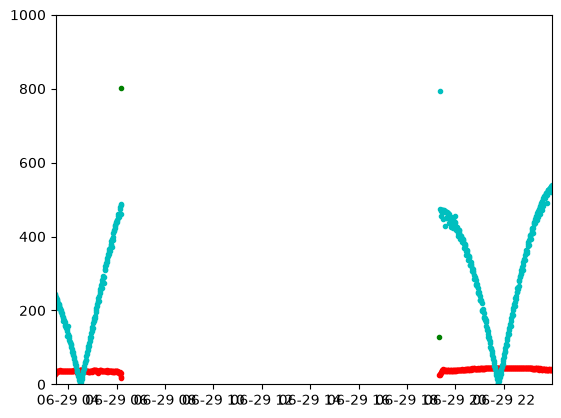

In [35]:
subdf = df[df.prn == "E02"]
print(subdf)
plt.plot(subdf.minbin, subdf.n_sigphi_1, ".g")
plt.xlim(subdf.minbin.iloc[10], subdf.minbin.iloc[-1])
plt.subplot()

plt.plot(subdf.minbin, subdf.snr1, ".r")
plt.xlim(subdf.minbin.iloc[10], subdf.minbin.iloc[-1])
plt.subplot()

plt.plot(subdf.minbin, subdf.sigma_phi_1, ".c")
plt.xlim(subdf.minbin.iloc[10], subdf.minbin.iloc[-1])
plt.ylim(0, 1000)

In [36]:
import pandas as pd

df["datetime"] = pd.to_datetime(df["datetime"])

# Pick one satellite (replace 1 with any PRN that exists)
prn = df["prn"].iloc[0]

sat = df[df["prn"] == prn].sort_values("datetime")

dt = sat["datetime"].diff().dt.total_seconds()

print("PRN:", prn)
print(dt.value_counts().head(10))

PRN: C09
datetime
60.00000        726
518418.21275      1
229.12500         1
52.65625          1
42447.75000       1
32.25000          1
Name: count, dtype: int64


In [38]:
print(df["n_sigphi_1"].describe())
print(df["n_sigphi_1"].value_counts().head(10))

count    52877.000000
mean      1154.547648
std        220.116046
min          0.000000
25%       1200.000000
50%       1200.000000
75%       1200.000000
max       1200.000000
Name: n_sigphi_1, dtype: float64
n_sigphi_1
1200    50083
0         623
40        213
38        174
1198      171
4         111
39        108
2          80
1186       63
5          45
Name: count, dtype: int64
